In [2]:
import os
import pandas as pd
import numpy as np
import random
import optuna
import json
import math
import time

# Sembunyikan log Optuna agar terminal bersih
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_FOLDER = os.path.join('osmnx_inputs')

try:
    # Memuat berkas data dasar dari folder target
    matriks_jarak = pd.read_csv(os.path.join(TARGET_FOLDER, 'distance_matrix_osmnx.csv'), index_col=0)
    matriks_jalan = pd.read_csv(os.path.join(TARGET_FOLDER, 'road_condition_matrix_osmnx.csv'), index_col=0)
    matriks_elevasi = pd.read_csv(os.path.join(TARGET_FOLDER, 'elevation_matrix_surabaya.csv'), index_col=0)
    df_cluster = pd.read_csv(os.path.join(TARGET_FOLDER, 'destinasi_clustered_real_distance.csv'))
    
    ROUTE_JSON_PATH = os.path.join(TARGET_FOLDER, 'route_polyline_registry.json')
    with open(ROUTE_JSON_PATH, 'r') as f:
        route_registry = json.load(f)
        
    names = matriks_jarak.index.tolist()

    # Konversi ke NumPy Array untuk komputasi cepat di dalam engine algoritma
    dist_np = matriks_jarak.to_numpy()
    road_np = matriks_jalan.to_numpy()
    elev_np = matriks_elevasi.to_numpy()
    cluster_np = df_cluster['Cluster_ID'].to_numpy()

    print("=" * 65)
    print("🚲 PRE-FLIGHT SANITY CHECK: KAPASITAS USER")
    print("=" * 65)

    BANNED_NODES = []
    MAX_KM_USER = 20.10
    
    while True:
        try:
            input_user = input("\nMasukkan batas maksimal jarak per hari (Km) [Tekan Enter untuk default 20.10]: ")
            if input_user.strip():
                MAX_KM_USER = float(input_user)
            else:
                MAX_KM_USER = 25.0
        except ValueError:
            print("❌ Masukkan angka yang valid!")
            continue

        max_m = MAX_KM_USER * 1000
        infeasible_nodes = []

        for i in range(1, len(names)):
            jarak_pp = dist_np[0, i] + dist_np[i, 0]
            if jarak_pp > max_m:
                infeasible_nodes.append((i, names[i], jarak_pp))

        if infeasible_nodes:
            print(f"\n⚠️ WARNING: Ditemukan {len(infeasible_nodes)} destinasi yang jarak PP-nya saja sudah melebihi {MAX_KM_USER} km!")
            for idx, nama, jarak in infeasible_nodes:
                print(f"   - {nama} (Jarak PP mutlak: {round(jarak/1000, 2)} km)")
            
            opsi = input("\nApakah kamu ingin MENGHAPUS destinasi di atas agar model tetap feasible? (y/n): ").strip().lower()
            if opsi == 'y':
                print("✅ Destinasi infeasible di-blacklist dari pencarian rute.")
                BANNED_NODES = [n[0] for n in infeasible_nodes]
                break
            else:
                print("❌ Pencarian dibatalkan. Silakan masukkan limit yang lebih besar untuk menjangkau destinasi tersebut.")
        else:
            BANNED_NODES = []
            print("✅ Semua destinasi lolos uji kapasitas fisik harian!")
            break

except FileNotFoundError as e:
    print(f"[ERROR] Berkas data preprocessing tidak ditemukan: {e}")

🚲 PRE-FLIGHT SANITY CHECK: KAPASITAS USER
✅ Semua destinasi lolos uji kapasitas fisik harian!


In [26]:
# ─────────────────────────────────────────────────────────────────────
# 1. FUNGSI FITNESS ACO 
# ─────────────────────────────────────────────────────────────────────
def hitung_fitness_aco_final(solusi_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user):
    w_jarak = 10.0
    w_jalan = 5.0
    w_penalti_cluster = 50.0 
    w_hari = 30.0  
    
    fitness_total = len(solusi_multi_hari) * w_hari
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        if idx_hari % 2 != 0:
            nama_hari = f"Pekan {(idx_hari+1)//2} - Sabtu (Jalan Berat)"
            w_penalti_fatigue = 1.5; w_penalti_jarak = 5.0     
        else:
            nama_hari = f"Pekan {idx_hari//2} - Minggu (Recovery)"
            w_penalti_fatigue = 8.0; w_penalti_jarak = 25.0    
            
        jarak_m = fatigue = skor_jalan = p_cluster = 0.0
        
        for k in range(len(rute) - 1):
            a, t = rute[k], rute[k+1]
            
            dm = dist_np[a, t]
            dz = elev_np[a, t]
            js = road_np[a, t]
            
            jarak_m += dm
            skor_jalan += js
            
            if dz > 0 and dm > 0: 
                fatigue += dm * ((dz / dm) ** 2) * 400.0
            else: 
                fatigue += dm * 0.0001
                
            if a != 0 and t != 0:
                if cluster_np[a-1] != cluster_np[t-1]:
                    p_cluster += w_penalti_cluster

        jkm = jarak_m / 1000.0
        p_jarak = max(0.0, jkm - max_km_user) * w_penalti_jarak  
        p_fatigue = fatigue * w_penalti_fatigue
            
        fitness_hari = (jkm * w_jarak) + (skor_jalan * w_jalan) + p_jarak + p_fatigue + p_cluster
        fitness_total += fitness_hari
        
        log_itinerary.append({
            "Hari/Trip": nama_hari, "Jarak (Km)": round(jkm, 2),
            "Fatigue Index": round(fatigue, 2), "Skor Jalan OSMnx": round(skor_jalan, 2),
            "P_Fatigue": round(p_fatigue, 2), "P_Cluster": round(p_cluster, 2)
        })
        
    return fitness_total, log_itinerary

# ─────────────────────────────────────────────────────────────────────
# 2. CORE ENGINE ACO (DENGAN BLACKLIST NODE)
# ─────────────────────────────────────────────────────────────────────
# TAMBAHAN: Parameter banned_nodes dimasukkan ke engine
def run_aco_final(dist_np, elev_np, road_np, cluster_np, alpha, beta, evaporation, max_km_user, banned_nodes, num_ants=15, iterations=30):
    num_nodes = len(dist_np)
    max_m = max_km_user * 1000
    pheromone = np.full((num_nodes, num_nodes), 0.1)
    
    max_dist = dist_np.max()
    max_elev = elev_np.max() 
    if max_elev <= 0: max_elev = 1.0 
    
    best_score = float('inf')
    best_route = []
    best_log = None
    
    # Trackers untuk Grafik Konvergensi
    hist_fitness = []
    hist_dist = []
    hist_days = []
    
    for _ in range(iterations):
        list_solusi_semut = []
        list_fitness_semut = []
        list_log_semut = []
        
        for ant in range(num_ants):
            # FILTER BLACKLIST: Semut hanya melihat destinasi yang tidak di-banned
            destinasi_tersisa = [i for i in range(1, num_nodes) if i not in banned_nodes]
            rute_multi_hari = []
            
            while len(destinasi_tersisa) > 0:
                rute_hari_ini = [0]
                jarak_hari = 0.0
                
                while len(destinasi_tersisa) > 0:
                    curr = rute_hari_ini[-1]
                    
                    valid_candidates = []
                    for cand in destinasi_tersisa:
                        uji_dist = dist_np[curr, cand]
                        jarak_kembali_hotel = dist_np[cand, 0]
                        if jarak_hari + uji_dist + jarak_kembali_hotel <= max_m:
                            valid_candidates.append(cand)
                            
                    if not valid_candidates:
                        break 
                        
                    probs = []
                    for cand in valid_candidates:
                        tau = pheromone[curr][cand] ** alpha
                        d_ij = dist_np[curr, cand]
                        road_ij = road_np[curr, cand]
                        dz = elev_np[curr, cand]
                        
                        d_norm = d_ij / max_dist
                        r_norm = road_ij / 5.0
                        
                        cluster_norm = 0.0
                        if curr != 0 and cand != 0:
                            if cluster_np[curr-1] != cluster_np[cand-1]: 
                                cluster_norm = 0.15 
                                
                        if len(rute_multi_hari) % 2 == 0:
                            eta = 1.0 / (0.8 * d_norm + 0.2 * r_norm + cluster_norm + 0.001)
                        else:
                            f_local = max(0, dz)
                            f_norm = f_local / (max_elev + 1e-6) 
                            eta = 1.0 / (0.5 * d_norm + 0.2 * r_norm + 0.3 * f_norm + cluster_norm + 0.001)
                            
                        probs.append(tau * (eta ** beta))
                        
                    sum_p = sum(probs)
                    if sum_p == 0: next_c = random.choice(valid_candidates)
                    else: next_c = random.choices(valid_candidates, weights=[p/sum_p for p in probs], k=1)[0]
                    
                    rute_hari_ini.append(next_c)
                    jarak_hari += dist_np[curr, next_c]
                    destinasi_tersisa.remove(next_c)
                    
                rute_hari_ini.append(0)
                
                if len(rute_hari_ini) == 2:
                    raise ValueError(f"Infeasible Error Lolos: Terdapat rute destinasi yang jarak PP-nya melebihi {max_km_user} km.")
                
                rute_multi_hari.append(rute_hari_ini)
                
            f_score, lg = hitung_fitness_aco_final(rute_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user)
            list_solusi_semut.append(rute_multi_hari)
            list_fitness_semut.append(f_score)
            list_log_semut.append(lg)
            
            if f_score < best_score:
                best_score = f_score
                best_route = rute_multi_hari
                best_log = lg
                
        pheromone *= (1.0 - evaporation)
        for idx, solusi in enumerate(list_solusi_semut):
            fit_value = list_fitness_semut[idx]
            if fit_value > 0:
                deposit = 2000 / fit_value
                for rute in solusi:
                    for k in range(len(rute) - 1):
                        pheromone[rute[k]][rute[k+1]] += deposit
        
        # Simpan metrik terbaik per iterasi
        hist_fitness.append(best_score)
        tot_dist = sum(l["Jarak (Km)"] for l in best_log)
        hist_dist.append(tot_dist)
        hist_days.append(len(best_route))
                        
    return best_score, best_route, best_log, hist_fitness, hist_dist, hist_days

print("\n" + "=" * 65)
print("🐜 TUNING PARAMETER ACO FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_aco(trial):
    alpha = trial.suggest_float('alpha', 0.1, 1.5)
    beta = trial.suggest_float('beta', 2.0, 8.0)
    evaporation = trial.suggest_float('evaporation', 0.05, 0.5)
    score, _, _, _, _, _ = run_aco_final(dist_np, elev_np, road_np, cluster_np, alpha, beta, evaporation, max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_ants=15, iterations=15)
    return score

study_aco = optuna.create_study(direction='minimize')
study_aco.optimize(objective_aco, n_trials=20)
best_p_aco = study_aco.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final ACO dengan Parameter Terbaik...")
score_aco, rute_aco, log_aco, hist_fitness_aco, hist_dist_aco, hist_days_aco = run_aco_final(
    dist_np, elev_np, road_np, cluster_np, alpha=best_p_aco['alpha'], beta=best_p_aco['beta'], evaporation=best_p_aco['evaporation'], max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_ants=40, iterations=50
)
print(f"✔ [ACO Selesai] Fitness Score Terbaik: {round(score_aco, 2)}")


🐜 TUNING PARAMETER ACO FINAL DENGAN DATASET OSMNX LOKAL

▶ Mengeksekusi Eksperimen Final ACO dengan Parameter Terbaik...
✔ [ACO Selesai] Fitness Score Terbaik: 32233.53


In [4]:
def buat_solusi_awal_sa(num_nodes, dist_np, max_km_user, banned_nodes):
    destinasi_tersisa = [i for i in range(1, num_nodes) if i not in banned_nodes]
    random.shuffle(destinasi_tersisa)
    max_m = max_km_user * 1000; solusi_multi_hari = []; rute_hari_ini = [0]; jarak_hari = 0.0
    
    for cand in destinasi_tersisa:
        curr = rute_hari_ini[-1]
        if jarak_hari + dist_np[curr, cand] + dist_np[cand, 0] <= max_m:
            rute_hari_ini.append(cand); jarak_hari += dist_np[curr, cand]
        else:
            rute_hari_ini.append(0); solusi_multi_hari.append(rute_hari_ini)
            rute_hari_ini = [0, cand]; jarak_hari = dist_np[0, cand]
    rute_hari_ini.append(0); solusi_multi_hari.append(rute_hari_ini)
    return solusi_multi_hari

def modifikasi_solusi_tetangga_sa(solusi_sekarang, dist_np, max_km_user):
    urutan_flat = [node for rute in solusi_sekarang for node in rute if node != 0]
    if len(urutan_flat) > 1:
        idx1, idx2 = random.sample(range(len(urutan_flat)), 2)
        urutan_flat[idx1], urutan_flat[idx2] = urutan_flat[idx2], urutan_flat[idx1]
        
    max_m = max_km_user * 1000; solusi_baru = []; rute_hari_ini = [0]; jarak_hari = 0.0
    for cand in urutan_flat:
        curr = rute_hari_ini[-1]
        if jarak_hari + dist_np[curr, cand] + dist_np[cand, 0] <= max_m:
            rute_hari_ini.append(cand); jarak_hari += dist_np[curr, cand]
        else:
            rute_hari_ini.append(0); solusi_baru.append(rute_hari_ini)
            rute_hari_ini = [0, cand]; jarak_hari = dist_np[0, cand]
    rute_hari_ini.append(0); solusi_baru.append(rute_hari_ini)
    return solusi_baru

def run_sa_final(dist_np, elev_np, road_np, cluster_np, temp_awal, cooling_rate, temp_min, max_km_user, banned_nodes, seed=42):
    random.seed(seed); num_nodes = len(dist_np)
    solusi_sekarang = buat_solusi_awal_sa(num_nodes, dist_np, max_km_user, banned_nodes)
    best_score, best_log = hitung_fitness_aco_final(solusi_sekarang, dist_np, elev_np, road_np, cluster_np, max_km_user)
    best_route = solusi_sekarang; score_sekarang = best_score; t = temp_awal
    
    while t > temp_min:
        solusi_tetangga = modifikasi_solusi_tetangga_sa(solusi_sekarang, dist_np, max_km_user)
        score_tetangga, log_tetangga = hitung_fitness_aco_final(solusi_tetangga, dist_np, elev_np, road_np, cluster_np, max_km_user)
        delta_energi = score_tetangga - score_sekarang
        
        if delta_energi < 0 or random.random() < math.exp(-delta_energi / t):
            solusi_sekarang = solusi_tetangga; score_sekarang = score_tetangga
            if score_sekarang < best_score:
                best_score = score_sekarang; best_route = solusi_sekarang; best_log = log_tetangga
        t *= cooling_rate
    return best_score, best_route, best_log

print("\n" + "=" * 65)
print("🌡️  TUNING PARAMETER SA FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_sa(trial):
    temp_awal = trial.suggest_float('temp_awal', 1000.0, 5000.0)
    cooling_rate = trial.suggest_float('cooling_rate', 0.990, 0.9999)
    temp_min = trial.suggest_float('temp_min', 0.001, 1.0, log=True)
    score, _, _ = run_sa_final(dist_np, elev_np, road_np, cluster_np, temp_awal, cooling_rate, temp_min, max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, seed=42)
    return score

study_sa = optuna.create_study(direction='minimize')
study_sa.optimize(objective_sa, n_trials=20)
best_p_sa = study_sa.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final SA dengan Parameter Terbaik...")
score_sa, rute_sa, log_sa = run_sa_final(
    dist_np, elev_np, road_np, cluster_np, temp_awal=best_p_sa['temp_awal'], cooling_rate=best_p_sa['cooling_rate'], temp_min=best_p_sa['temp_min'], max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, seed=42
)
print(f"✔ [SA Selesai] Fitness Score Terbaik: {round(score_sa, 2)}")


🌡️  TUNING PARAMETER SA FINAL DENGAN DATASET OSMNX LOKAL

▶ Mengeksekusi Eksperimen Final SA dengan Parameter Terbaik...
✔ [SA Selesai] Fitness Score Terbaik: 28167.95


In [22]:
def buat_partikel_nn_pso(num_nodes, dist_np, max_km_user, banned_nodes, noise=0.0):
    """
    Bangun partikel awal dengan heuristik Nearest-Neighbor dari depot.
    noise=0   -> murni nearest-neighbor (deterministik)
    noise>0   -> ada probabilitas memilih kandidat ke-2/ke-3 terdekat
                 (untuk variasi antar partikel "smart" agar tidak identik)
    """
    destinasi_tersisa = set(i for i in range(1, num_nodes) if i not in banned_nodes)
    urutan = []
    curr = 0
    while destinasi_tersisa:
        kandidat = sorted(destinasi_tersisa, key=lambda x: dist_np[curr, x])
        if noise > 0 and len(kandidat) > 1 and random.random() < noise:
            pilih = kandidat[random.randint(1, min(2, len(kandidat) - 1))]
        else:
            pilih = kandidat[0]
        urutan.append(pilih)
        destinasi_tersisa.remove(pilih)
        curr = pilih
    return urutan

def buat_partikel_awal_pso(num_nodes, dist_np, max_km_user, banned_nodes):
    """Partikel awal full-random (permutasi acak murni)."""
    destinasi_tersisa = [i for i in range(1, num_nodes) if i not in banned_nodes]
    random.shuffle(destinasi_tersisa)
    return destinasi_tersisa

def permutasi_ke_solusi_multi_hari(urutan_flat, dist_np, max_km_user):
    """Potong permutasi flat menjadi rute multi-hari berdasarkan batas Km harian."""
    max_m = max_km_user * 1000; solusi = []; rute_hari_ini = [0]; jarak_hari = 0.0
    for cand in urutan_flat:
        curr = rute_hari_ini[-1]
        if jarak_hari + dist_np[curr, cand] + dist_np[cand, 0] <= max_m:
            rute_hari_ini.append(cand); jarak_hari += dist_np[curr, cand]
        else:
            rute_hari_ini.append(0); solusi.append(rute_hari_ini)
            rute_hari_ini = [0, cand]; jarak_hari = dist_np[0, cand]
    rute_hari_ini.append(0); solusi.append(rute_hari_ini)
    return solusi

def swap_sequence_pso(urutan_a, urutan_b):
    """Hitung Swap Sequence (SO) yang mengubah urutan_a -> urutan_b."""
    a = list(urutan_a); b = list(urutan_b); swaps = []
    for i in range(len(b)):
        if a[i] != b[i]:
            j = a.index(b[i], i)
            swaps.append((i, j)); a[i], a[j] = a[j], a[i]
    return swaps

def terapkan_swaps_parsial_pso(urutan, swaps, probabilitas):
    """Terapkan tiap swap dalam Swap Sequence dengan probabilitas tertentu."""
    r = list(urutan)
    for i, j in swaps:
        if random.random() < probabilitas:
            r[i], r[j] = r[j], r[i]
    return r

def local_search_2swap_pso(urutan, dist_np, elev_np, road_np, cluster_np, max_km_user, score_sekarang, n_coba=3):
    """
    Local search ringan: coba beberapa 2-swap acak, terima kalau lebih baik.
    Dipilih kembali dari 2-opt karena 2-opt (segment reversal) terbukti
    destruktif pada representasi "permutasi-terpotong-per-hari" -- reversal
    di tengah permutasi mengubah drastis bagaimana sisa permutasi terpotong
    jadi hari-hari berikutnya (efek domino), sedangkan 2-swap hanya
    mempertukarkan dua node sehingga dampaknya lebih lokal & terkendali.
    """
    best_urutan = urutan
    best_score = score_sekarang
    for _ in range(n_coba):
        cand = best_urutan[:]
        ia, ib = random.sample(range(len(cand)), 2)
        cand[ia], cand[ib] = cand[ib], cand[ia]
        sol = permutasi_ke_solusi_multi_hari(cand, dist_np, max_km_user)
        s, lg = hitung_fitness_aco_final(sol, dist_np, elev_np, road_np, cluster_np, max_km_user)
        if s < best_score:
            best_score = s; best_urutan = cand
    return best_urutan, best_score


def run_pso_final(dist_np, elev_np, road_np, cluster_np, w, c1, c2, max_km_user, banned_nodes,
                  num_particles=15, iterations=30, seed=42, n_elite=2):
    random.seed(seed); np.random.seed(seed)
    num_nodes = len(dist_np)

    # ── Inisialisasi swarm HYBRID ────────────────────────────────────
    # ~50% partikel: Nearest-Neighbor (smart start, dengan noise antar partikel)
    # ~50% partikel: full-random (diversitas/eksplorasi)
    particles = []
    n_smart = max(1, int(0.5 * num_particles))
    for _ in range(n_smart):
        particles.append(buat_partikel_nn_pso(num_nodes, dist_np, max_km_user, banned_nodes, noise=0.3))
    for _ in range(num_particles - n_smart):
        particles.append(buat_partikel_awal_pso(num_nodes, dist_np, max_km_user, banned_nodes))

    pbest_perm = [p[:] for p in particles]
    pbest_score = []
    pbest_log = []
    for p in particles:
        solusi = permutasi_ke_solusi_multi_hari(p, dist_np, max_km_user)
        s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)
        pbest_score.append(s); pbest_log.append(lg)

    gbest_idx = int(np.argmin(pbest_score))
    gbest_perm = pbest_perm[gbest_idx][:]
    gbest_score = pbest_score[gbest_idx]
    gbest_route = permutasi_ke_solusi_multi_hari(gbest_perm, dist_np, max_km_user)
    gbest_log = pbest_log[gbest_idx]

    # Normalisasi bobot velocity: w + c1 + c2 dipetakan jadi probabilitas
    total_w = w + c1 + c2

    # ── Loop utama PSO ────────────────────────────────────────────────
    for _ in range(iterations):
        # Elitism: urutkan partikel berdasarkan pbest_score saat ini,
        # n_elite terbaik dilindungi dari inersia acak (tetap dapat
        # kognitif/sosial + local search lebih intensif)
        urutan_elite = set(np.argsort(pbest_score)[:n_elite].tolist())

        for i in range(num_particles):
            r1 = random.random(); r2 = random.random()
            perm = particles[i][:]
            is_elite = i in urutan_elite

            # Inersia: swap acak kecil sebagai eksplorasi/momentum.
            # Partikel elite TIDAK kena inersia acak (dilindungi).
            if not is_elite:
                n_inertia_swap = max(0, round((w / total_w) * 3))
                for _ in range(n_inertia_swap):
                    ia, ib = random.sample(range(len(perm)), 2)
                    perm[ia], perm[ib] = perm[ib], perm[ia]

            # Kognitif: tarik proporsional ke personal best
            prob_cog = (c1 * r1) / total_w
            perm = terapkan_swaps_parsial_pso(perm, swap_sequence_pso(perm, pbest_perm[i]), prob_cog)

            # Sosial: tarik proporsional ke global best
            prob_soc = (c2 * r2) / total_w
            perm = terapkan_swaps_parsial_pso(perm, swap_sequence_pso(perm, gbest_perm), prob_soc)

            # Validasi permutasi
            if set(perm) == set(particles[i]):
                particles[i] = perm

            solusi = permutasi_ke_solusi_multi_hari(particles[i], dist_np, max_km_user)
            s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)

            # Local search 2-swap (perbaikan halus).
            # Partikel elite mendapat lebih banyak percobaan local search.
            n_coba = 6 if is_elite else 3
            new_perm, new_s = local_search_2swap_pso(
                particles[i], dist_np, elev_np, road_np, cluster_np, max_km_user, s, n_coba=n_coba
            )
            if new_s < s:
                particles[i] = new_perm; s = new_s
                solusi = permutasi_ke_solusi_multi_hari(particles[i], dist_np, max_km_user)
                s, lg = hitung_fitness_aco_final(solusi, dist_np, elev_np, road_np, cluster_np, max_km_user)

            if s < pbest_score[i]:
                pbest_score[i] = s; pbest_perm[i] = particles[i][:]; pbest_log[i] = lg

            if s < gbest_score:
                gbest_score = s; gbest_perm = particles[i][:]
                gbest_route = solusi; gbest_log = lg

    return gbest_score, gbest_route, gbest_log


print("\n" + "=" * 65)
print("🕊️  TUNING PARAMETER PSO FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_pso(trial):
    w = trial.suggest_float('w', 0.1, 0.9)
    c1 = trial.suggest_float('c1', 0.5, 2.5)
    c2 = trial.suggest_float('c2', 0.5, 2.5)
    score, _, _ = run_pso_final(dist_np, elev_np, road_np, cluster_np, w, c1, c2, max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_particles=20, iterations=20, seed=42)
    return score

study_pso = optuna.create_study(direction='minimize')
study_pso.optimize(objective_pso, n_trials=20)
best_p_pso = study_pso.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final PSO dengan Parameter Terbaik...")
score_pso, rute_pso, log_pso = run_pso_final(
    dist_np, elev_np, road_np, cluster_np, w=best_p_pso['w'], c1=best_p_pso['c1'], c2=best_p_pso['c2'], max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, num_particles=60, iterations=100, seed=42
)
print(f"✔ [PSO Selesai] Fitness Score Terbaik: {round(score_pso, 2)}")


🕊️  TUNING PARAMETER PSO FINAL DENGAN DATASET OSMNX LOKAL

▶ Mengeksekusi Eksperimen Final PSO dengan Parameter Terbaik...
✔ [PSO Selesai] Fitness Score Terbaik: 31005.13


In [28]:
# ─────────────────────────────────────────────────────────────────────
# 1. FUNGSI FITNESS GA (MULTI-WEEKEND & TERKALIBRASI LOKAL)
# ─────────────────────────────────────────────────────────────────────
def hitung_fitness_ga_final(solusi_multi_hari, dist_np, elev_np, road_np, cluster_np, max_km_user):
    w_jarak = 10.0
    w_jalan = 5.0
    w_penalti_cluster = 50.0 
    w_hari = 30.0  
    
    fitness_total = len(solusi_multi_hari) * w_hari
    log_itinerary = []
    
    for idx_hari, rute in enumerate(solusi_multi_hari, start=1):
        if idx_hari % 2 != 0:
            nama_hari = f"Pekan {(idx_hari+1)//2} - Sabtu (Jalan Berat)"
            w_penalti_fatigue = 1.5; w_penalti_jarak = 5.0     
        else:
            nama_hari = f"Pekan {idx_hari//2} - Minggu (Recovery)"
            w_penalti_fatigue = 8.0; w_penalti_jarak = 25.0    
            
        jarak_m = fatigue = skor_jalan = p_cluster = 0.0
        
        for k in range(len(rute) - 1):
            a, t = rute[k], rute[k+1]
            
            dm = dist_np[a, t]
            dz = elev_np[a, t]
            js = road_np[a, t]
            
            jarak_m += dm
            skor_jalan += js
            
            if dz > 0 and dm > 0: 
                fatigue += dm * ((dz / dm) ** 2) * 400.0
            else: 
                fatigue += dm * 0.0001
                
            if a != 0 and t != 0:
                if cluster_np[a-1] != cluster_np[t-1]:
                    p_cluster += w_penalti_cluster

        jkm = jarak_m / 1000.0
        p_jarak = max(0.0, jkm - max_km_user) * w_penalti_jarak  
        p_fatigue = fatigue * w_penalti_fatigue
            
        fitness_hari = (jkm * w_jarak) + (skor_jalan * w_jalan) + p_jarak + p_fatigue + p_cluster
        fitness_total += fitness_hari
        
        log_itinerary.append({
            "Hari/Trip": nama_hari, "Jarak (Km)": round(jkm, 2),
            "Fatigue Index": round(fatigue, 2), "Skor Jalan OSMnx": round(skor_jalan, 2),
            "P_Fatigue": round(p_fatigue, 2), "P_Cluster": round(p_cluster, 2)
        })
        
    return fitness_total, log_itinerary

# ─────────────────────────────────────────────────────────────────────
# 2. MECHANISM GA ENGINE (DENGAN FILTER BLACKLIST NODE)
# ─────────────────────────────────────────────────────────────────────
def buat_kromosom_acak_clean(num_nodes, banned_nodes):
    # FILTER BLACKLIST: Kromosom hanya dibentuk dari node yang tidak di-banned
    k = [i for i in range(1, num_nodes) if i not in banned_nodes]
    random.shuffle(k)
    return k

def decode_kromosom_clean(kromo, dist_np, max_km_user):
    max_m = max_km_user * 1000; hasil = []; sisa = list(kromo)
    while sisa:
        rute = [0]; jarak = 0.0
        while sisa:
            pos = rute[-1]; tuj = sisa[0]
            dtuj = dist_np[pos, tuj]
            if (jarak + dtuj > max_m) and (random.random() > 0.15): break
            rute.append(tuj); jarak += dtuj; sisa.pop(0)
        rute.append(0); hasil.append(rute)
    return hasil

def order_crossover(p1, p2):
    n = len(p1); a, b = sorted(random.sample(range(n), 2))
    anak = [None]*n; anak[a:b+1] = p1[a:b+1]
    sisa = [g for g in p2 if g not in anak[a:b+1]]
    ptr = 0
    for i in range(n):
        if anak[i] is None: anak[i] = sisa[ptr]; ptr += 1
    return anak

def swap_mutation(k, prob):
    k = k[:]
    if random.random() < prob:
        i, j = random.sample(range(len(k)), 2); k[i], k[j] = k[j], k[i]
    return k

def tournament_selection(pop, fit, k):
    idx = random.sample(range(len(pop)), k)
    return pop[min(idx, key=lambda i: fit[i])][:]

# ─────────────────────────────────────────────────────────────────────
# 3. CORE ENGINE GA RUNNER (KEMBAR IDENTIK PANGGILAN DENGAN ACO)
# ─────────────────────────────────────────────────────────────────────
def run_ga_final(dist_np, elev_np, road_np, cluster_np, pop_size, prob_cross, prob_mut, tournament_k, max_km_user, banned_nodes, iterations=100):
    num_nodes = len(dist_np)
    populasi = [buat_kromosom_acak_clean(num_nodes, banned_nodes) for _ in range(pop_size)]
    
    best_score = float('inf')
    best_route = []
    best_log = None
    
    for gen in range(1, iterations + 1):
        fit_list = []; log_list = []
        for k in populasi:
            rute = decode_kromosom_clean(k, dist_np, max_km_user)
            f_score, lg = hitung_fitness_ga_final(rute, dist_np, elev_np, road_np, cluster_np, max_km_user)
            fit_list.append(f_score); log_list.append(lg)

        idx_best = int(np.argmin(fit_list))
        if fit_list[idx_best] < best_score:
            best_score = fit_list[idx_best]
            best_route = decode_kromosom_clean(populasi[idx_best], dist_np, max_km_user)
            best_log = log_list[idx_best]

        # Operasi Evolusi Reproduksi Populasi
        sorted_idx = np.argsort(fit_list)
        elit = [populasi[i][:] for i in sorted_idx[:2]] # N_ELITE = 2
        generasi_baru = elit[:]
        while len(generasi_baru) < pop_size:
            p1 = tournament_selection(populasi, fit_list, tournament_k)
            p2 = tournament_selection(populasi, fit_list, tournament_k)
            if random.random() < prob_cross:
                a1 = order_crossover(p1, p2); a2 = order_crossover(p2, p1)
            else:
                a1, a2 = p1[:], p2[:]
            generasi_baru.append(swap_mutation(a1, prob_mut))
            if len(generasi_baru) < pop_size: generasi_baru.append(swap_mutation(a2, prob_mut))
        populasi = generasi_baru
        
    return best_score, best_route, best_log

print("\n" + "=" * 65)
print("🧬 TUNING PARAMETER GA FINAL DENGAN DATASET OSMNX LOKAL")
print("=" * 65)

def objective_ga(trial):
    pop_size = trial.suggest_int('pop_size', 10, 30, step=5)  # disesuaikan setara dengan num_particles pso
    prob_cross = trial.suggest_float('prob_crossover', 0.6, 0.95)
    prob_mut = trial.suggest_float('prob_mutasi', 0.01, 0.3)
    tournament_k = trial.suggest_int('tournament_k', 2, 6)
    
    score, _, _ = run_ga_final(
        dist_np, elev_np, road_np, cluster_np, 
        pop_size=pop_size, prob_cross=prob_cross, prob_mut=prob_mut, tournament_k=tournament_k,
        max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, iterations=20
    )
    return score

study_ga = optuna.create_study(direction='minimize')
study_ga.optimize(objective_ga, n_trials=20)
best_p_ga = study_ga.best_params

print(f"\n▶ Mengeksekusi Eksperimen Final GA dengan Parameter Terbaik...")
score_ga, rute_ga, log_ga = run_ga_final(
    dist_np, elev_np, road_np, cluster_np, 
    pop_size=60,  # Dibuat setara 60 (identik dengan num_particles=60 milik PSO Anda)
    prob_cross=best_p_ga['prob_crossover'], 
    prob_mut=best_p_ga['prob_mutasi'], 
    tournament_k=int(best_p_ga['tournament_k']),
    max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, iterations=100
)
print(f"✔ [GA Selesai] Fitness Score Terbaik: {round(score_ga, 2)}")

[W 2026-06-14 17:03:34,082] Trial 0 failed with parameters: {'pop_size': 10, 'prob_crossover': 0.8396268764979172, 'prob_mutasi': 0.17008425481455958, 'tournament_k': 5} because of the following error: TypeError("run_ga_final() got an unexpected keyword argument 'seed'").
Traceback (most recent call last):
  File "/Users/mac/sc_env/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/lk/wc9vhhns1fn7k7j4sx2dl0t00000gn/T/ipykernel_66071/2956324615.py", line 148, in objective_ga
    score, _, _ = run_ga_final(
                  ~~~~~~~~~~~~^
        dist_np, elev_np, road_np, cluster_np,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        pop_size=pop_size, prob_cross=prob_cross, prob_mut=prob_mut, tournament_k=tournament_k,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        max_km_user=MAX_KM_USER, banned_nodes=BANNED_NODES, iterations=20, seed=42
   


🧬 TUNING PARAMETER GA FINAL DENGAN DATASET OSMNX LOKAL


TypeError: run_ga_final() got an unexpected keyword argument 'seed'

In [ ]:
print("\n" + "=" * 65)
print("📊  EKSPERIMEN STATISTIK — 10 RUN PER ALGORITMA")
print("=" * 65)

NUM_RUNS = 10

def jalankan_statistik(nama, fungsi_run, kwargs_dasar, supports_seed=True, seed_awal=1000):
    """
    Jalankan fungsi_run sebanyak NUM_RUNS kali, catat skor & waktu.

    supports_seed=True  -> tiap run diberi kwarg 'seed' berbeda (reproducible & beragam)
    supports_seed=False -> fungsi tidak punya parameter seed (mis. run_aco_final),
                           jadi random.seed() di-set manual sebelum memanggil fungsi
                           agar tiap run tetap punya kondisi awal acak yang berbeda.
    """
    scores, times = [], []
    for run in range(1, NUM_RUNS + 1):
        kwargs = dict(kwargs_dasar)

        if supports_seed:
            kwargs['seed'] = seed_awal + run
        else:
            random.seed(seed_awal + run)
            np.random.seed(seed_awal + run)

        t0 = time.time()
        score = fungsi_run(**kwargs)[0]
        t1 = time.time()

        scores.append(score); times.append(t1 - t0)
        print(f"  {nama} | Run {run:02d} | Fitness: {score:.2f} | Waktu: {t1 - t0:.2f}s")

    return {
        "scores": scores,
        "times": times,
        "avg": float(np.mean(scores)),
        "std": float(np.std(scores)),
        "min": float(np.min(scores)),
        "avg_time": float(np.mean(times)),
    }

# ── ACO — 10 run dengan parameter terbaik dari Optuna ────────────────
# run_aco_final TIDAK punya parameter 'seed' -> supports_seed=False
print("\n🐜 ACO — 10 Run")
stat_aco = jalankan_statistik(
    "ACO", run_aco_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "alpha": best_p_aco['alpha'], "beta": best_p_aco['beta'], "evaporation": best_p_aco['evaporation'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "num_ants": 40, "iterations": 50,
    },
    supports_seed=False
)

# ── SA — 10 run dengan parameter terbaik dari Optuna ──────────────────
# run_sa_final SUDAH punya parameter 'seed' -> supports_seed=True
print("\n🌡️  SA — 10 Run")
stat_sa = jalankan_statistik(
    "SA", run_sa_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "temp_awal": best_p_sa['temp_awal'], "cooling_rate": best_p_sa['cooling_rate'], "temp_min": best_p_sa['temp_min'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
    },
    supports_seed=True
)

# ── PSO — 10 run dengan parameter terbaik dari Optuna ─────────────────
# run_pso_final SUDAH punya parameter 'seed' -> supports_seed=True
print("\n🕊️  PSO — 10 Run")
stat_pso = jalankan_statistik(
    "PSO", run_pso_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "w": best_p_pso['w'], "c1": best_p_pso['c1'], "c2": best_p_pso['c2'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "num_particles": 40, "iterations": 50,
    },
    supports_seed=True
)

# ── GA — 10 run dengan parameter terbaik dari Optuna ─────────────────
# run_ga_final SUDAH punya parameter 'seed' -> supports_seed=True
print("\n🕊️  GA — 10 Run")
stat_ga = jalankan_statistik(
    "GA", run_ga_final,
    {
        "dist_np": dist_np, "elev_np": elev_np, "road_np": road_np, "cluster_np": cluster_np,
        "w": best_p_ga['w'], "c1": best_p_ga['c1'], "c2": best_p_ga['c2'],
        "max_km_user": MAX_KM_USER, "banned_nodes": BANNED_NODES,
        "num_particles": 40, "iterations": 50,
    },
    supports_seed=True
)

# ── Ringkasan tabel ────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("📋  RINGKASAN STATISTIK 10 RUN")
print("=" * 65)

df_statistik = pd.DataFrame({
    "Algoritma": ["ACO", "SA", "GA"],
    "Avg Fitness": [stat_aco["avg"], stat_sa["avg"], stat_ga["avg"]],
    "Std Dev": [stat_aco["std"], stat_sa["std"], stat_ga["std"]],
    "Min Fitness (Best)": [stat_aco["min"], stat_sa["min"], stat_ga["min"]],
    "Avg Running Time (s)": [stat_aco["avg_time"], stat_sa["avg_time"], stat_ga["avg_time"]],
})
df_statistik = df_statistik.round(3)
print(df_statistik.to_string(index=False))


📊  EKSPERIMEN STATISTIK — 10 RUN PER ALGORITMA

🐜 ACO — 10 Run
  ACO | Run 01 | Fitness: 33142.01 | Waktu: 2.72s
  ACO | Run 02 | Fitness: 33275.13 | Waktu: 2.76s
  ACO | Run 03 | Fitness: 31841.39 | Waktu: 2.82s
  ACO | Run 04 | Fitness: 31816.93 | Waktu: 2.73s


KeyboardInterrupt: 


📈  VISUALISASI GRAFIK PERBANDINGAN ALGORITMA


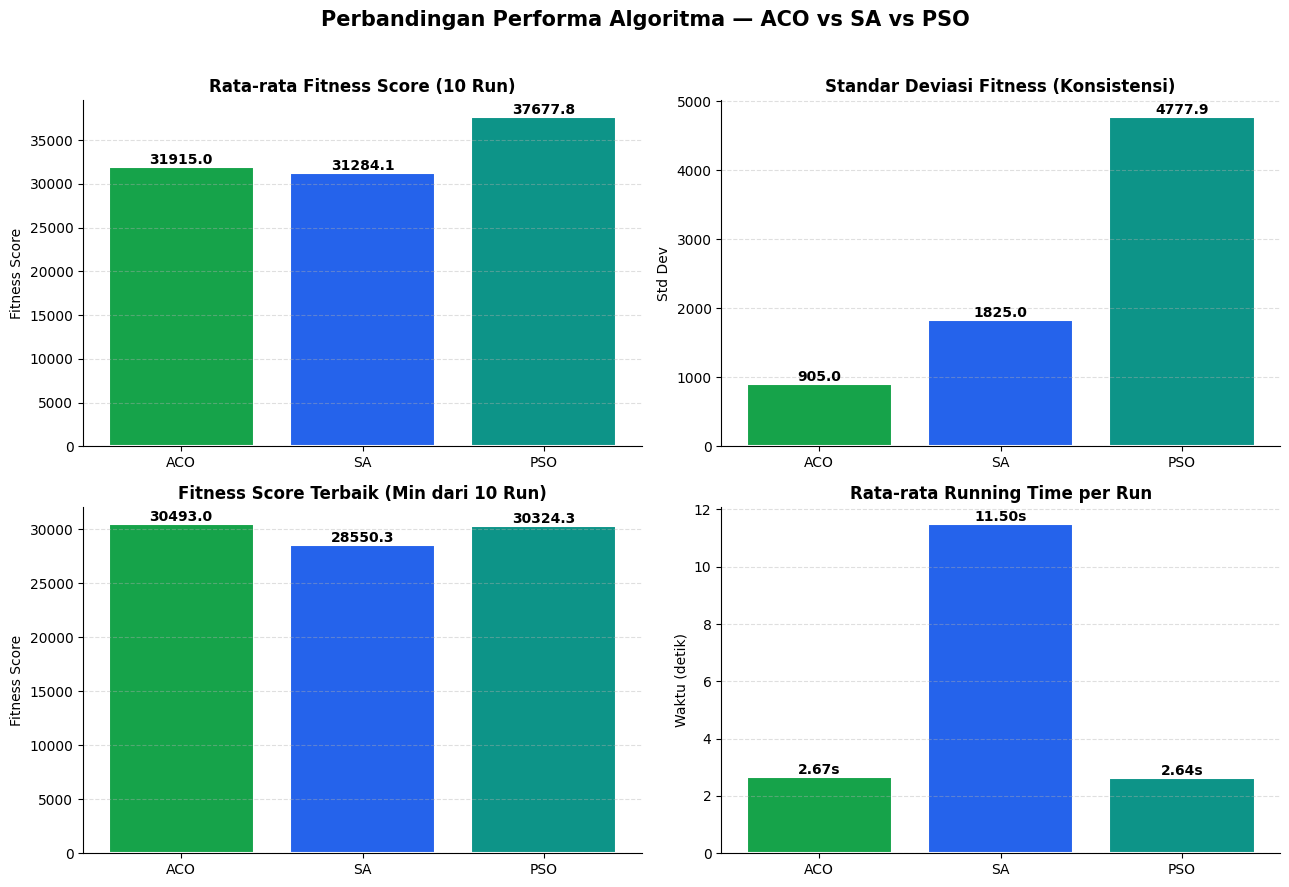

/var/folders/lk/wc9vhhns1fn7k7j4sx2dl0t00000gn/T/ipykernel_66071/3428728929.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_scores, labels=algo_names, patch_artist=True, widths=0.5)


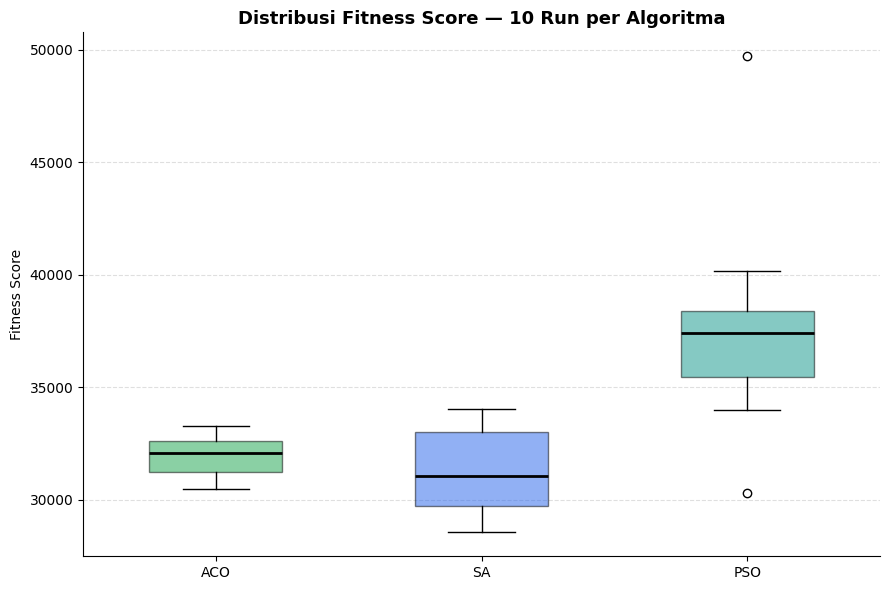

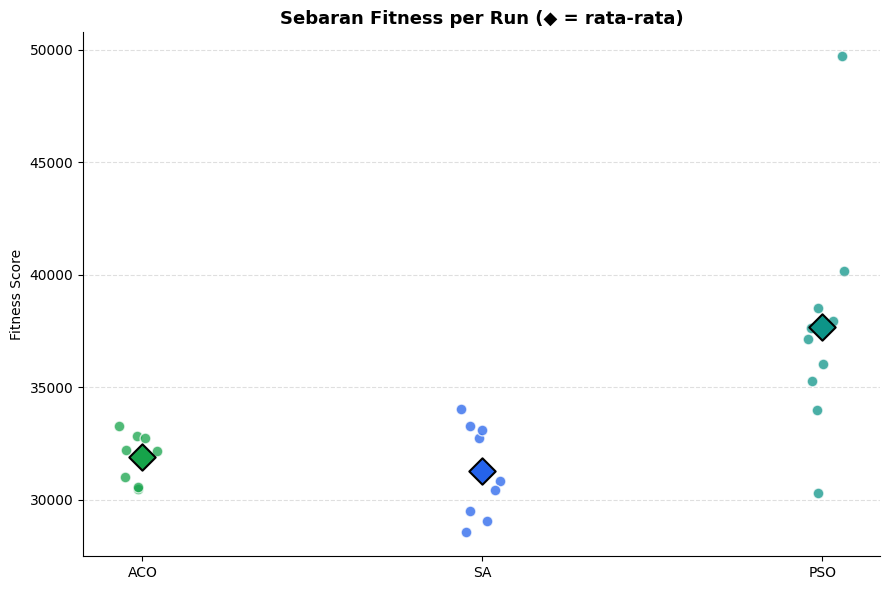

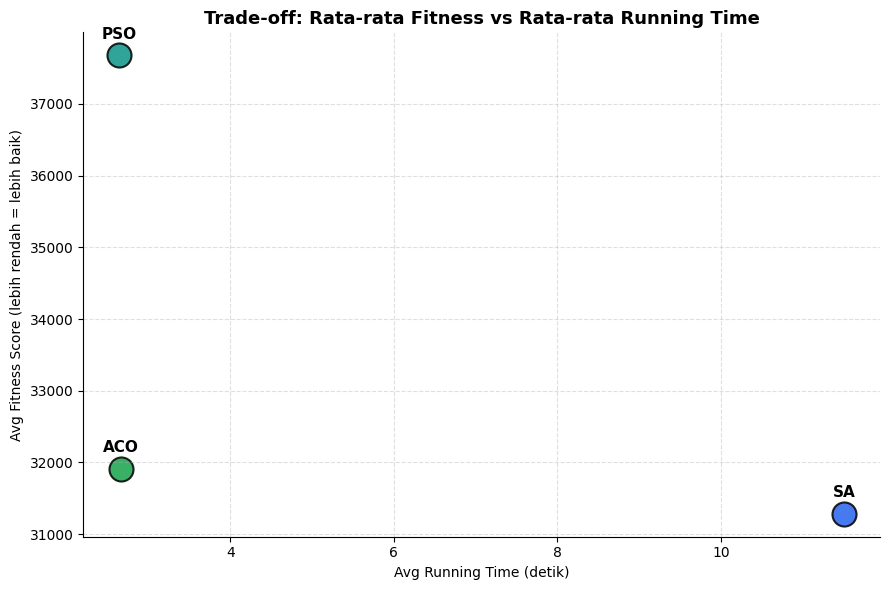


✅ Semua grafik tersimpan: perbandingan_metrik_algoritma.png, boxplot_distribusi_fitness.png, scatter_fitness_per_run.png, tradeoff_fitness_runtime.png

📝 Catatan: GA belum diikutkan dalam grafik karena belum selesai diimplementasikan.
   Setelah GA siap, tambahkan 'GA' ke algo_names dan stat_ga ke array data di atas.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 65)
print("📈  VISUALISASI GRAFIK PERBANDINGAN ALGORITMA")
print("=" * 65)

# ── Siapkan data perbandingan ───────────────────────────────────────
algo_names = ["ACO", "SA", "PSO", "GA"]
colors     = {"ACO": "#16a34a", "SA": "#2563eb", "PSO": "#0d9488", "GA": "#9b59b6"}

avg_scores = [stat_aco["avg"], stat_sa["avg"], stat_pso["avg"], stat_ga["avg"]]
std_scores = [stat_aco["std"], stat_sa["std"], stat_pso["std"], stat_ga["std"]]
min_scores = [stat_aco["min"], stat_sa["min"], stat_pso["min"], stat_ga["min"]]
avg_times  = [stat_aco["avg_time"], stat_sa["avg_time"], stat_pso["avg_time"], stat_ga["avg_time"]]
all_scores = [stat_aco["scores"], stat_sa["scores"], stat_pso["scores"], stat_ga["scores"]]

bar_colors = [colors[a] for a in algo_names]


# ════════════════════════════════════════════════════════════════════
# FIGURE 1 — Grid 2x2: Avg Fitness, Std Dev, Min Fitness, Avg Runtime
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Perbandingan Performa Algoritma — ACO vs SA vs PSO vs GA", fontsize=15, fontweight='bold')

# 1. Avg Fitness
ax = axes[0, 0]
bars = ax.bar(algo_names, avg_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Rata-rata Fitness Score (10 Run)", fontweight='bold')
ax.set_ylabel("Fitness Score")
for b, v in zip(bars, avg_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 2. Std Dev (konsistensi)
ax = axes[0, 1]
bars = ax.bar(algo_names, std_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Standar Deviasi Fitness (Konsistensi)", fontweight='bold')
ax.set_ylabel("Std Dev")
for b, v in zip(bars, std_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 3. Min Fitness (Best)
ax = axes[1, 0]
bars = ax.bar(algo_names, min_scores, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Fitness Score Terbaik (Min dari 10 Run)", fontweight='bold')
ax.set_ylabel("Fitness Score")
for b, v in zip(bars, min_scores):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

# 4. Avg Running Time
ax = axes[1, 1]
bars = ax.bar(algo_names, avg_times, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_title("Rata-rata Running Time per Run", fontweight='bold')
ax.set_ylabel("Waktu (detik)")
for b, v in zip(bars, avg_times):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s", ha='center', va='bottom', fontweight='bold')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('perbandingan_metrik_algoritma.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 2 — Boxplot distribusi fitness 10 run per algoritma
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(all_scores, labels=algo_names, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(c); patch.set_alpha(0.5)
for median in bp['medians']:
    median.set_color('black'); median.set_linewidth(2)

ax.set_title("Distribusi Fitness Score — 10 Run per Algoritma", fontweight='bold', fontsize=13)
ax.set_ylabel("Fitness Score")
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('boxplot_distribusi_fitness.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 3 — Scatter: Fitness tiap run (sebaran 10 titik per algoritma)
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for i, (algo, scores) in enumerate(zip(algo_names, all_scores)):
    x = np.full(len(scores), i) + np.random.uniform(-0.08, 0.08, len(scores))
    ax.scatter(x, scores, color=colors[algo], s=60, alpha=0.75, edgecolor='white', linewidth=1, label=algo)
    ax.scatter(i, np.mean(scores), color=colors[algo], s=180, marker='D', edgecolor='black', linewidth=1.5, zorder=5)

ax.set_xticks(range(len(algo_names)))
ax.set_xticklabels(algo_names)
ax.set_title("Sebaran Fitness per Run (◆ = rata-rata)", fontweight='bold', fontsize=13)
ax.set_ylabel("Fitness Score")
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_fitness_per_run.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 4 — Trade-off: Fitness vs Running Time (scatter besar)
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for algo, avgf, avgt in zip(algo_names, avg_scores, avg_times):
    ax.scatter(avgt, avgf, s=300, color=colors[algo], edgecolor='black', linewidth=1.5, label=algo, alpha=0.85)
    ax.annotate(algo, (avgt, avgf), textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold', fontsize=11)

ax.set_title("Trade-off: Rata-rata Fitness vs Rata-rata Running Time", fontweight='bold', fontsize=13)
ax.set_xlabel("Avg Running Time (detik)")
ax.set_ylabel("Avg Fitness Score (lebih rendah = lebih baik)")
ax.grid(linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tradeoff_fitness_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua grafik tersimpan: perbandingan_metrik_algoritma.png, "
      "boxplot_distribusi_fitness.png, scatter_fitness_per_run.png, tradeoff_fitness_runtime.png")
print("\n📝 GA sudah diikutkan dalam seluruh grafik perbandingan di atas.")

In [ ]:
def generate_dashboard(rute_terbaik, log_metrik, names, route_registry, target_folder):
    print("\n" + "=" * 65)
    print("🌍 MEMBUAT DASHBOARD PETA INTERAKTIF...")
    
    # OUTPUT disesuaikan dengan dashboard utama multi-algoritma jika ingin digabung
    OUTPUT_DASHBOARD = os.path.join(target_folder, 'dashboard_interaktif_multi_algo.html')
    
    data_metrik = []
    for log in log_metrik:
        data_metrik.append({
            "hari": log["Hari/Trip"], "jarak": log["Jarak (Km)"],
            "fatigue": log["Fatigue Index"], "jalan": log["Skor Jalan OSMnx"]
        })
        
    data_rute_js = []
    for rute in rute_terbaik:
        hari_data = []
        for k in range(len(rute) - 1):
            idx_asal = rute[k]; idx_tujuan = rute[k+1]
            key = f"{idx_asal}_{idx_tujuan}"
            
            if key in route_registry:
                hari_data.append({
                    "asal_nama": names[idx_asal], "tujuan_nama": names[idx_tujuan],
                    "is_depot_asal": (idx_asal == 0), "is_depot_tujuan": (idx_tujuan == 0),
                    "jalur": route_registry[key] 
                })
        data_rute_js.append(hari_data)

    json_rute_str = json.dumps(data_rute_js)
    json_metrik_str = json.dumps(data_metrik)

    html_content = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Dashboard Optimasi Rute Sepeda - Surabaya</title>
        <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
        <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
        <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
        <style>
            body {{ margin: 0; padding: 0; font-family: 'Inter', sans-serif; display: flex; height: 100vh; background-color: #f8f9fa; }}
            #map-container {{ flex: 1; height: 100%; position: relative; }}
            #map {{ height: 100%; width: 100%; }}
            .legend {{ position: absolute; bottom: 30px; left: 30px; z-index: 1000; background: white; padding: 15px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }}
            .legend-title {{ font-weight: bold; margin-bottom: 8px; font-size: 14px; }}
            .gradient-bar {{ width: 250px; height: 15px; border-radius: 4px; background: linear-gradient(to right, #27ae60, #f1c40f, #e74c3c); }}
            .legend-labels {{ display: flex; justify-content: space-between; margin-top: 5px; font-size: 12px; color: #555; }}
            #sidebar {{ width: 400px; height: 100%; background: white; box-shadow: -2px 0 10px rgba(0,0,0,0.1); overflow-y: auto; padding: 20px; box-sizing: border-box; z-index: 1000; }}
            
            /* TABS NAVIGATION STYLING */
            .tabs-nav {{ display: flex; gap: 5px; margin-bottom: 15px; border-bottom: 2px solid #e0e6ed; padding-bottom: 5px; }}
            .tab-btn {{ flex: 1; padding: 8px; border: none; background: #e2e8f0; font-weight: bold; cursor: pointer; border-radius: 4px; font-size: 12px; transition: all 0.2s; }}
            .tab-btn.active {{ background: #2980b9; color: white; }}
            #algo-badge {{ display: inline-block; padding: 4px 10px; border-radius: 20px; font-size: 11px; font-weight: bold; color: white; margin-bottom: 15px; }}
            #algo-badge.ga {{ background-color: #9b59b6; }}
            
            h2 {{ margin-top: 0; color: #2c3e50; font-size: 18px; padding-bottom: 5px; margin-bottom: 2px; }}
            .card {{ background: #ffffff; border: 1px solid #e0e6ed; border-radius: 8px; padding: 15px; margin-bottom: 15px; cursor: pointer; transition: all 0.3s ease; }}
            .card:hover {{ transform: translateY(-3px); box-shadow: 0 5px 15px rgba(0,0,0,0.08); border-color: #2980b9; }}
            .card.active {{ border: 2px solid #2980b9; background-color: #f0f7fb; }}
            .card-header {{ font-weight: 700; color: #2c3e50; margin-bottom: 10px; font-size: 15px; }}
            .badge {{ display: inline-block; padding: 3px 8px; border-radius: 12px; font-size: 11px; font-weight: bold; color: white; margin-bottom: 10px; }}
            .badge.sabtu {{ background-color: #e74c3c; }}
            .badge.minggu {{ background-color: #27ae60; }}
            .metric-row {{ display: flex; justify-content: space-between; margin-bottom: 5px; font-size: 13px; color: #555; }}
            .metric-val {{ font-weight: bold; color: #2c3e50; }}
            #btn-semua {{ width: 100%; padding: 12px; background: #34495e; color: white; border: none; border-radius: 6px; font-weight: bold; cursor: pointer; margin-bottom: 20px; transition: background 0.2s; }}
            #btn-semua:hover {{ background: #2c3e50; }}
        </style>
    </head>
    <body>
        <div id="map-container">
            <div id="map"></div>
            <div class="legend">
                <div class="legend-title">Elevasi Tanjakan Rute (m)</div>
                <div class="gradient-bar"></div>
                <div class="legend-labels"><span>0m (Datar)</span><span>Landai</span><span>>25m (Berat)</span></div>
            </div>
        </div>
        <div id="sidebar">
            <div class="tabs-nav">
                <button class="tab-btn" onclick="switchTab('sa')">SA</button>
                <button class="tab-btn" onclick="switchTab('aco')">ACO</button>
                <button class="tab-btn" onclick="switchTab('pso')">PSO</button>
                <button class="tab-btn active" onclick="switchTab('ga')">GA (Slot)</button>
            </div>
            <div id="algo-badge" class="ga">GENETIC ALGORITHM</div>
            <h2 id="sidebar-title">Itinerary Multi-Hari — GA</h2>
            <button id="btn-semua" onclick="tampilkanSemuaRute()">Tampilkan Seluruh Rute</button>
            <div id="cards-container"></div>
        </div>
        <script>
            // Data rute di-capsulate dalam object berdasarkan algoritma masing-masing
            const masterRute = {{ "ga": {json_rute_str}, "sa": [], "aco": [], "pso": [] }}; 
            const masterMetrik = {{ "ga": {json_metrik_str}, "sa": [], "aco": [], "pso": [] }};
            
            let activeAlgo = 'ga';
            const map = L.map('map').setView([-7.262015, 112.739727], 13);
            L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
                attribution: '&copy; OpenStreetMap contributors &copy; CARTO'
            }}).addTo(map);

            let layerGroup = L.layerGroup().addTo(map);

            function getColorForElevation(elev) {{
                const minE = 0, midE = 12.5, maxE = 25;
                let val = Math.max(minE, Math.min(elev, maxE)); let r, g, b;
                if (val <= midE) {{
                    let ratio = val / midE;
                    r = Math.round(0x27 + ratio * (0xf1 - 0x27)); g = Math.round(0xae + ratio * (0xc4 - 0xae)); b = Math.round(0x60 + ratio * (0x0f - 0x60));
                }} else {{
                    let ratio = (val - midE) / (maxE - midE);
                    r = Math.round(0xf1 + ratio * (0xe7 - 0xf1)); g = Math.round(0xc4 + ratio * (0x4c - 0xc4)); b = Math.round(0x0f + ratio * (0x3c - 0x0f));
                }}
                return `rgb(${{r}}, ${{g}}, ${{b}})`;
            }}

            function gambarRuteKePeta(arrayIndexHari) {{
                layerGroup.clearLayers(); let bounds = []; let markersDitaruh = new Set();
                const currentDataRute = masterRute[activeAlgo];
                if (!currentDataRute || currentDataRute.length === 0) return;

                arrayIndexHari.forEach(idx_hari => {{
                    const ruteSatuHari = currentDataRute[idx_hari];
                    if(!ruteSatuHari) return;
                    ruteSatuHari.forEach(segmen => {{
                        const polyline = segmen.jalur;
                        for (let i = 0; i < polyline.length - 1; i++) {{
                            let p1 = polyline[i]; let p2 = polyline[i+1]; let elevRata = (p1[2] + p2[2]) / 2;
                            L.polyline([[p1[0], p1[1]], [p2[0], p2[1]]], {{ color: getColorForElevation(elevRata), weight: 5, opacity: 0.85 }}).addTo(layerGroup);
                            bounds.push([p1[0], p1[1]]);
                        }}
                        const titikAwal = polyline[0]; const titikAkhir = polyline[polyline.length - 1];
                        if (!markersDitaruh.has(segmen.asal_nama)) {{
                            let warnaIkon = segmen.is_depot_asal ? 'orange' : '#3498db';
                            L.circleMarker([titikAwal[0], titikAwal[1]], {{ radius: segmen.is_depot_asal ? 8 : 6, color: 'white', weight: 2, fillColor: warnaIkon, fillOpacity: 1 }}).bindPopup(`<b>${{segmen.asal_nama}}</b><br>Elevasi: ${{titikAwal[2].toFixed(1)}}m`).addTo(layerGroup);
                            markersDitaruh.add(segmen.asal_nama);
                        }}
                        if (!markersDitaruh.has(segmen.tujuan_nama)) {{
                            let warnaIkon = segmen.is_depot_tujuan ? 'orange' : '#3498db';
                            L.circleMarker([titikAkhir[0], titikAkhir[1]], {{ radius: segmen.is_depot_tujuan ? 8 : 6, color: 'white', weight: 2, fillColor: warnaIkon, fillOpacity: 1 }}).bindPopup(`<b>${{segmen.tujuan_nama}}</b><br>Elevasi: ${{titikAkhir[2].toFixed(1)}}m`).addTo(layerGroup);
                            markersDitaruh.add(segmen.tujuan_nama);
                        }}
                    }});
                }});
                if(bounds.length > 0) map.fitBounds(bounds, {{padding: [30, 30]}});
            }}

            function tampilkanSemuaRute() {{
                document.querySelectorAll('.card').forEach(c => c.classList.remove('active'));
                gambarRuteKePeta(masterMetrik[activeAlgo].map((_, i) => i));
            }}

            function buildCards() {{
                const container = document.getElementById('cards-container');
                container.innerHTML = '';
                const currentMetrik = masterMetrik[activeAlgo];
                
                currentMetrik.forEach((metrik, idx) => {{
                    let isSabtu = metrik.hari.toLowerCase().includes('sabtu');
                    let badgeClass = isSabtu ? 'sabtu' : 'minggu';
                    let badgeText = isSabtu ? 'HEAVY CLIMB' : 'RECOVERY';
                    let card = document.createElement('div'); card.className = 'card';
                    card.innerHTML = `
                        <div class="badge ${{badgeClass}}">${{badgeText}}</div>
                        <div class="card-header">${{metrik.hari}}</div>
                        <div class="metric-row"><span>Total Jarak:</span> <span class="metric-val">${{metrik.jarak.toFixed(2)}} Km</span></div>
                        <div class="metric-row"><span>Fatigue Index:</span> <span class="metric-val">${{metrik.fatigue.toFixed(2)}}</span></div>
                        <div class="metric-row"><span>Skor Jalan:</span> <span class="metric-val">${{metrik.jalan.toFixed(2)}}</span></div>
                    `;
                    card.onclick = () => {{
                        document.querySelectorAll('.card').forEach(c => c.classList.remove('active'));
                        card.classList.add('active'); gambarRuteKePeta([idx]);
                    }};
                    container.appendChild(card);
                }});
            }}

            function switchTab(algo) {{
                activeAlgo = algo;
                document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
                document.querySelector(`.tab-btn:nth-child(${{algo==='sa'?1:algo==='aco'?2:algo==='pso'?3:4}})`).classList.add('active');
                
                const badge = document.getElementById('algo-badge');
                badge.className = algo;
                badge.textContent = algo === 'ga' ? 'GENETIC ALGORITHM' : algo.toUpperCase();
                
                document.getElementById('sidebar-title').textContent = 'Itinerary Multi-Hari — ' + algo.toUpperCase();
                buildCards();
                tampilkanSemuaRute();
            }}

            window.onload = () => {{
                buildCards();
                tampilkanSemuaRute();
            }};
        </script>
    </body>
    </html>
    """
    with open(OUTPUT_DASHBOARD, "w", encoding="utf-8") as file:
        file.write(html_content)
    print(f"🎉 SELESAI! Dashboard Terintegrasi diekspor ke: {OUTPUT_DASHBOARD}")

print(f"\n▶ Membuat dashboard interaktif untuk hasil GA...")
generate_dashboard(rute_ga, log_ga, names, route_registry, TARGET_FOLDER)

🎉 DASHBOARD MULTI-ALGORITMA (SA · ACO · PSO · GA-slot) SELESAI! Berkas diekspor ke: osmnx_inputs/dashboard_multi_algoritma_final.html
